In [1]:
using Pkg
Pkg.activate("$(ENV["DIVA_LIB"])")
include("$(ENV["DIVA_LIB"])/src/DIVACoast.jl")
using .DIVACoast
using Plots
using GeoArrays

  Activating project at `C:\Users\Lars\Work\Global_Climate_Forum\DIVA\DIVACoast`
┌ Warning: Replacing docs for `Main.DIVACoast.neighbours :: Tuple{AbstractArray, CartesianIndex{2}}` in module `Main.DIVACoast`
└ @ Base.Docs docs\Docs.jl:243


┌                                       ┐
│ DIVACoast.jl | © GLOBAL CLIMATE FORUM │
└                                       ┘


In [2]:
# Set paths
data_path = subdir -> "$(ENV["DIVA_DATA"])/spatial_flood_model_comparison_UKIRL/uk_wash_floodplain/aligned/$(subdir)"

#15 (generic function with 1 method)

# Data Pipeline

## Load Datasets

All required datasets are loaded as GeoArray. The required datasets are: 

1. **Elevation:** A digital elevation model providing an elevation value for each pixel within the region of interest. Here we use the FABDEM.
2. **Water Bodies:** A mask defining ocean, land, and river pixel. Here we use the Copernicus Water Body Mask.
3. **Land Cover:** A landcover datsets, to be transformed into local attenuation rates.
4. **Region of interest:** A binary mask, defining the region of interest (1).

In [40]:
elevation = data_path("fabdem.tif") |> GeoArrays.read
water_bodies = data_path("wbm.tif") |> GeoArrays.read
landcover = data_path("corine.tif") |> GeoArrays.read
fp_63840_mask = data_path("fp_63840_mask.tif") |> GeoArrays.read

4245x5516 Matrix{Int32} with AffineMap([0.00026949458523585647 0.0; 0.0 -0.00026949458523585647], [-0.5212025278461464, 53.714582750869965]) and CRS GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]

## Pre-processing
### Derrive "river beds"

In [34]:
water_body_classes = Dict(
    "no_water" => 0.0,
    "ocean" => 1.0,
    "lake" => 2.0,
    "river" => 3.0)

Dict{String, Float64} with 4 entries:
  "ocean"    => 1.0
  "no_water" => 0.0
  "lake"     => 2.0
  "river"    => 3.0

In [ ]:
# Elevation data

elevation[water_bodies .== water_body_classes["river"]] .= nothing

for river_idx in findall(water_bodies .== water_body_classes["river"])
    neighbors = nbvalues(elevation, river_idx; cursor = SpatialCursorRadial(3))
    println(neighbors)
end



# elevation[water_bodies .== water_body_classes["river"]]  # Set water bodies to 0 elevation
# plot(elevation, title="Elevation Data (FABDEM)", c=:terrain, clim=(0, 20))



Float32[0.0, 0.0, 6.04, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0

Excessive output truncated after 524288 bytes.

Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Float32[0.0, 0.0, 0.0, 0.0

# Create a spatial Flood Profile & mask

In [7]:

fp = SpatialFloodProfile(ga, seed = CartesianIndex(25, 5))
fpmasks = SpatialFloodProfileMask(fp)


SpatialFloodProfileMask{Bool}(Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], Bool[1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 0 0; 1 1 … 0 0], 601, 801)

# Inundate

In [8]:
inun1 = inundate(fp, fpmasks, 4.0, HydraulicConnectedBathtub())
inun2 = inundate(fp, fpmasks, 4.0, PathBasedAttenuatedBathtub(0.8))

801×601 Matrix{Float32}:
 Inf  Inf  Inf  Inf  Inf  Inf  Inf  …  Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf  …  Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
 Inf  Inf  Inf  Inf  Inf  Inf  Inf     Inf   Inf   Inf   Inf   Inf   Inf
  ⋮                        ⋮        ⋱   ⋮                             ⋮
 Inf  Inf  Inf  Inf  Inf  Inf  Inf      0.0   0.0   0.0   0.0   0.0   0.0
 Inf  Inf  Inf  Inf  Inf  Inf  Inf      0.0   0.0   0.0   0.0   0.0   0.0
 Inf  Inf  Inf  Inf  Inf 

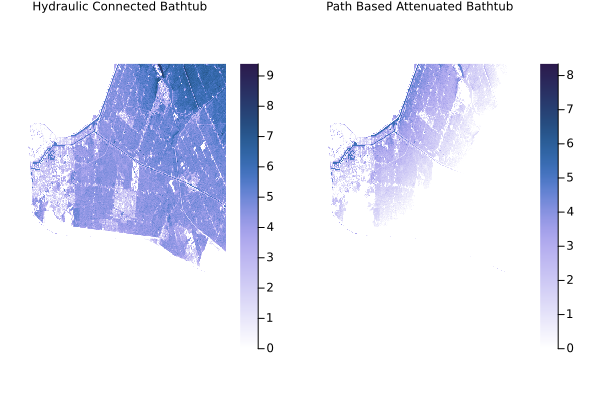

In [9]:
# Plotting the results
inun1 = inundate(fp, fpmasks, 4.0, HydraulicConnectedBathtub())
inun2 = inundate(fp, fpmasks, 4.0, PathBasedAttenuatedBathtub(0.8))

plot_args = Dict( 
                :colorbar => true, 
                :aspect_ratio => :equal, 
                :titlefontsize => 8, 
                :framestyle => :box, 
                :axis => ([], false)
)

p1 = heatmap(inun1, c = cgrad(:devon, rev=true), title = "Hydraulic Connected Bathtub"; plot_args...)
p2 = heatmap(inun2, c = cgrad(:devon, rev=true), title = "Path Based Attenuated Bathtub"; plot_args...)

plot(p1, p2, layout = @layout([a b])) |> display